# Rep 3. Checkpoint 2. Black Scholes y Volatility surface
## Eduardo Veytia Hernández


### Esta actividad es necesaria para la entrega del Reporte Integrador 3

Esta actividad puede ser realizada en parejas aunque la entrega es individual.

Usando el mismo activo trabajado en clase (SPY) y los parámetros disponibles en Notion, calcularás la volatilidad implícita para distintos strikes y analizarás el patrón que emerge.

### Contexto
El modelo de Black–Scholes asume que la volatilidad es constante para todos los strikes. En la práctica, el mercado no opera bajo ese supuesto — cada opción tiene un precio distinto que implica una volatilidad distinta. La curva que forman esas volatilidades se llama volatility skew, y es una de las señales más directas de cómo el mercado está distribuyendo el riesgo.



# Instrucciones
Usando el código visto en clase, calcula la volatilidad implícita para al menos 10 strikes distintos del vencimiento 2026-04-17, en el rango [S0 × 0.88, S0 × 1.10].

El precio spot y el precio mid de cada opción deben obtenerse dinámicamente — no hardcodear valores.

Con los resultados, construye dentro de tu código:

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


# Black-Scholes
def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        # Límite: precio intrínseco descontado
        if option == "call":
            return max(0.0, S - K*np.exp(-r*T))
        else:
            return max(0.0, K*np.exp(-r*T) - S)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option.lower() == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)  # en unidades de precio por 1.0 de sigma


def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):

    # Verificación de límites teóricos: el precio debe estar entre [intrínseco, cota superior]
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Ajusta el extremo superior si no cambia de signo (intenta ampliar)
    if fa*fb > 0:
        # intenta expandir b
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa*fb <= 0:
                b = b_try
                break

    # Intenta Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Si Brent falla, intenta método de Newton
    seed = min(max(sigma_hist if 'sigma_hist' in globals() and np.isfinite(sigma_hist) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita con los métodos intentados.")




In [13]:

ticker = 'SPY'

tk    = yf.Ticker(ticker)
exp = '2026-04-17'
today  = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
r     = 0.042
#K     = 680
T     = (date.fromisoformat(exp) - date.today()).days / 365

# solo informativo
#daily_returns = data.pct_change().dropna()
#sigma_hist = float(daily_returns.std() * np.sqrt(252))


# Precio mid: promedio de bid y ask, más estable que el último trade
#chain    = tk.option_chain(exp).calls
#row      = chain[chain['strike'] == K].iloc[0]
#C_market = (row['bid'] + row['ask']) / 2

#print(f"S0={S0:.2f} | bid={row['bid']:.2f} ask={row['ask']:.2f} mid={C_market:.4f}")
#iv = implied_vol(C_market, S0, K, r, T, option="call")

#bs_check = bs_price(S0, K, r, T, iv, option="call")
#error    = abs(bs_check - C_market)

#print(f"IV :        {iv:.4%}")
#print(f"BS, C (IV): {bs_check:.6f}")
#print(f"C_market     :{C_market:.6f}")

## Volatility surface

In [15]:
# --- NUEVA LÓGICA PARA EL CHECKPOINT 2 ---

# 1. Obtener la cadena de opciones completa para la fecha específica
chain = tk.option_chain(exp).calls

# 2. Definir rango dinámico [S0 * 0.88, S0 * 1.10]
lower_bound = S0 * 0.88
upper_bound = S0 * 1.10

# 3. Filtrar strikes y calcular Mid Price
df_task = chain[(chain['strike'] >= lower_bound) & (chain['strike'] <= upper_bound)].copy()
df_task['mid'] = (df_task['bid'] + df_task['ask']) / 2

# 4. Calcular IV para cada strike en el rango (Al menos 10)
iv_results = []
for idx, row in df_task.iterrows():
    try:
        # Usamos la función implied_vol de tu Chunk 1
        vol = implied_vol(row['mid'], S0, row['strike'], r, T, option="call")
        iv_results.append(vol * 100) # Guardamos en %
    except:
        iv_results.append(np.nan)

df_task['IV (%)'] = iv_results
df_task = df_task.dropna(subset=['IV (%)']) # Limpiamos errores de cálculo

### 1. Una tabla con columnas: Strike | Bid | Ask | Mid | IV (%)

In [16]:
print("\n--- TABLA DE RESULTADOS SPY 2026-04-17 ---")
tabla_final = df_task[['strike', 'bid', 'ask', 'mid', 'IV (%)']]
tabla_final.columns = ['Strike', 'Bid', 'Ask', 'Mid', 'IV (%)']
print(tabla_final.head(15).to_string(index=False))


--- TABLA DE RESULTADOS SPY 2026-04-17 ---
 Strike   Bid   Ask    Mid    IV (%)
  575.0 77.85 80.62 79.235 38.950142
  580.0 73.14 75.92 74.530 37.767817
  585.0 68.47 71.27 69.870 36.629245
  590.0 63.95 66.66 65.305 35.640906
  595.0 59.32 62.11 60.715 34.483451
  600.0 54.82 57.56 56.190 33.370494
  605.0 50.42 53.18 51.800 32.425199
  610.0 46.09 48.90 47.495 31.504520
  615.0 41.96 44.69 43.325 30.677514
  620.0 37.77 40.54 39.155 29.674180
  625.0 33.86 36.60 35.230 28.904298
  627.0 32.33 35.05 33.690 28.586281
  628.0 31.48 34.29 32.885 28.357926
  629.0 30.73 33.53 32.130 28.201531
  630.0 30.64 32.68 31.660 28.485561


### 2. Una gráfica de IV (%) vs. Strike, con una línea vertical en S0 indicando el precio ATM- . plt.plot(strikes, ivs)

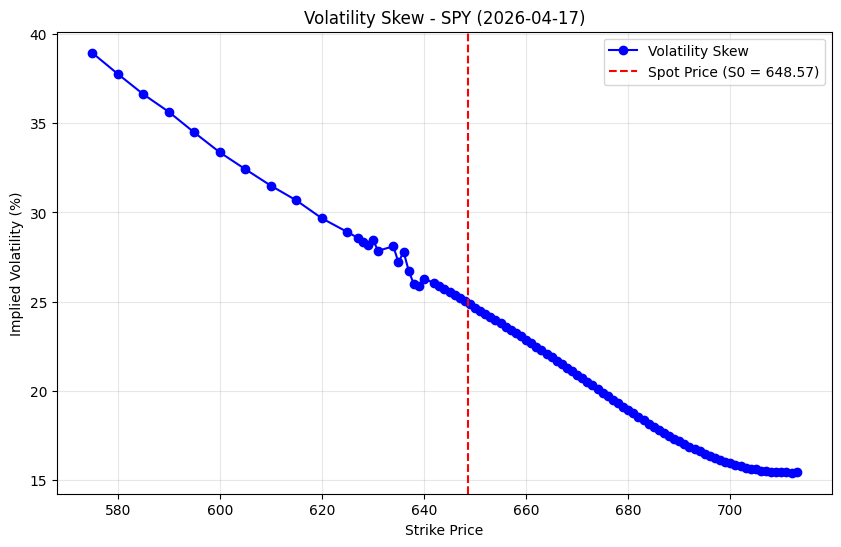

In [17]:
# 6. GRÁFICA DE IV (%) vs STRIKE
plt.figure(figsize=(10, 6))
plt.plot(df_task['strike'], df_task['IV (%)'], 'o-', label='Volatility Skew', color='blue')

# Línea vertical en S0 (Precio ATM)
plt.axvline(S0, color='red', linestyle='--', label=f'Spot Price (S0 = {S0:.2f})')

plt.title(f'Volatility Skew - SPY ({exp})')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Preguntas
Responde dentro del notebook como celdas de texto (Markdown):

**1. ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?**

Es decreciente.

Implicación: Esto indica que el mercado percibe un riesgo asimétrico. La volatilidad es mucho más alta en strikes bajos que en strikes altos.Los inversionistas temen mucho más una caída repentina del mercado que una subida acelerada.

**2. ¿En qué strike es mínima la IV? ¿Coincide con S0?**

Generalmente, la IV mínima se encuentra en los strikes ligeramente por encima de $S_0$, no exactamente en $S_0$.

Aunque el precio ATM ($S_0$) suele tener una IV moderada, el punto más bajo de la curva suele estar desplazado hacia la derecha.

**3. ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?**

Están comprando protección.

Pagar una IV alta significa que están pagando un sobreprecio por la opción. Los inversionistas institucionales compran Puts con strikes bajos para proteger sus portafolios contra un crash bursátil. Esa alta demanda infla el precio de esas opciones y, por lo tanto, dispara su volatilidad implícita.

**4. ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?**

Le diría que el supuesto de volatilidad constante es falso y que el mercado no distribuye los rendimientos de forma perfectamente normal (hay "colas pesadas" o riesgo de saltos negativos).
